# EMPIAR-10045: noise PSD and finite whitening-kernel support

This notebook loads the streamed patch RPSDs, reproduces the detector's ALS and variance calibration, constructs a regularized 3-D whitening response on a $Q=2P-1$ design grid, transforms it to a spatial impulse response, and evaluates finite support radii.

The support radius is selected from measured kernel decay and frequency-response error—not from particle diameter alone. The selected radius is also the halo required by a future streamed linear-convolution whitening stage.

In [1]:
from pathlib import Path
import pickle
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if repo_root.name == "experiments":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from kltpicker_3d.alt_least_squares import alternating_least_squares_solver
from kltpicker_3d.utils import (
    calibrate_radial_psds,
    construct_finite_whitening_filter,
)

RESULT_PATH = repo_root / "results" / "empiar-10045-rpsds.pkl"
KERNEL_OUTPUT_PATH = repo_root / "results" / "empiar-10045-whitening-kernel.npz"

ALS_MAX_ITER = 500
ALS_TOLERANCE = 1e-4
NOISE_PATCH_FRACTION = 0.25
REGULARIZATION_FRACTION = 0.1
CANDIDATE_RADII = (24, 37, 48, 60, 72)
SUPPORT_RADIUS = 37
TAPER_FRACTION = 0.2
MIN_RETAINED_ENERGY = 0.9999
MAX_RELATIVE_RESPONSE_ERROR = 0.01

print("JAX backend:", jax.default_backend())
print("RPSD input:", RESULT_PATH)

JAX backend: gpu
RPSD input: /scratch/home/moshemaymon/3D_KLT/results/empiar-10045-rpsds.pkl


## Load and validate the streamed RPSDs

In [2]:
with RESULT_PATH.open("rb") as stream:
    extraction = pickle.load(stream)

rpsds = np.asarray(extraction.rpsds, dtype=np.float32)
patch_variances = np.asarray(extraction.variances, dtype=np.float64)
radial_points = np.asarray(extraction.radial_points, dtype=np.float64)
patch_size = int(extraction.patch_size)
design_size = 2 * patch_size - 1

assert rpsds.ndim == 2
assert rpsds.shape[0] == patch_variances.size
assert rpsds.shape[1] == radial_points.size
assert np.isfinite(rpsds).all()
assert np.isfinite(patch_variances).all()
assert np.all(np.diff(radial_points) > 0)
assert max(CANDIDATE_RADII) < design_size // 2

print(f"Patch grid: {extraction.patch_grid_shape}")
print(f"RPSD matrix: {rpsds.shape}")
print(f"Patch size P: {patch_size}")
print(f"Kernel design size Q=2P-1: {design_size}")
print(
    "Patch variance percentiles:",
    np.percentile(patch_variances, (0, 25, 50, 75, 100)),
)

Patch grid: (5, 39, 41)
RPSD matrix: (7995, 93)
Patch size P: 93
Kernel design size Q=2P-1: 185
Patch variance percentiles: [  785253.3125 41011394.     47006456.     48744060.     50177824.    ]


## ALS factorization and variance calibration

The model is

$$S_j(\omega)=\alpha_j\,\Gamma(\omega)+N(\omega),$$

where $\Gamma$ is the particle RPSD and $N$ is the noise RPSD. The lowest-variance 25% of patches provide the robust spatial noise-variance scale, matching `KLTParticleDetector3D.factorize_rpsd`.

In [3]:
noise_patch_count = max(
    1,
    int(np.floor(NOISE_PATCH_FRACTION * patch_variances.size)),
)
noise_variance = float(
    np.mean(np.partition(patch_variances, noise_patch_count - 1)[:noise_patch_count])
)
mean_patch_variance = float(np.mean(patch_variances))

factorization = alternating_least_squares_solver(
    jnp.asarray(rpsds),
    ALS_MAX_ITER,
    ALS_TOLERANCE,
)
factorization = jax.device_get(factorization)

particle_psd, noise_psd = calibrate_radial_psds(
    radial_points,
    np.asarray(factorization.gamma),
    np.asarray(factorization.v),
    noise_variance,
    mean_patch_variance,
)

print(f"ALS iterations: {int(factorization.iter_num)}")
print(f"Lowest-variance patch count: {noise_patch_count}")
print(f"Estimated noise variance: {noise_variance:.6g}")
print(f"Mean patch variance: {mean_patch_variance:.6g}")

ALS iterations: 5
Lowest-variance patch count: 1998
Estimated noise variance: 2.84747e+07
Mean patch variance: 4.26418e+07


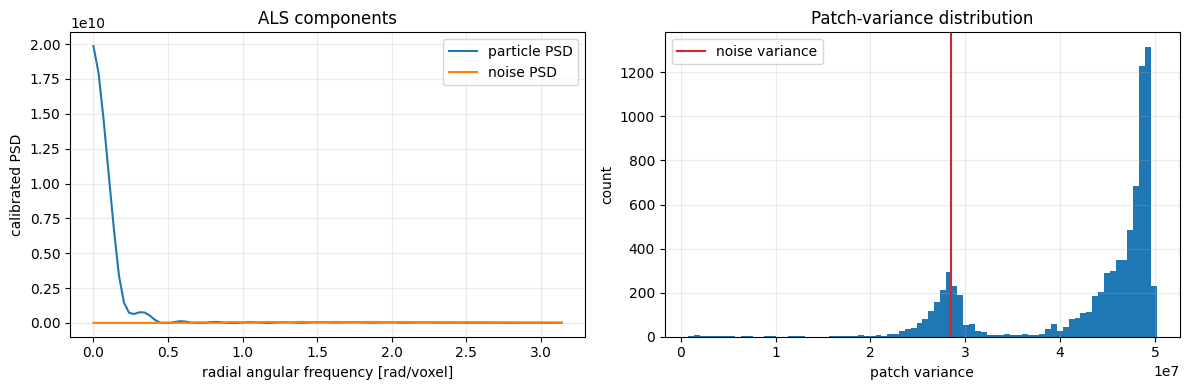

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(radial_points, particle_psd, label="particle PSD")
axes[0].plot(radial_points, noise_psd, label="noise PSD")
axes[0].set(
    xlabel="radial angular frequency [rad/voxel]",
    ylabel="calibrated PSD",
    title="ALS components",
)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].hist(patch_variances, bins=80)
axes[1].axvline(noise_variance, color="tab:red", label="noise variance")
axes[1].set(
    xlabel="patch variance",
    ylabel="count",
    title="Patch-variance distribution",
)
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Construct the full whitening impulse response

The radial noise PSD is regularized and interpolated onto a centered $(2P-1)^3=185^3$ design grid. Frequencies beyond the inscribed Nyquist sphere use the final radial PSD value, matching the existing `prewhiten_tomogram` convention.

$$W(\boldsymbol\omega)=\frac{1}{\sqrt{N(\boldsymbol\omega)+\epsilon}},\qquad h(\mathbf{x})=\mathcal{F}^{-1}\{W\}.$$

In [5]:
stable_noise_psd = np.maximum(noise_psd, 0)
regularizer = REGULARIZATION_FRACTION * np.median(stable_noise_psd)
stable_noise_psd = stable_noise_psd + regularizer

frequency_axis = 2 * np.pi * np.fft.fftshift(
    np.fft.fftfreq(design_size, d=1.0)
)
wz, wy, wx = np.meshgrid(
    frequency_axis,
    frequency_axis,
    frequency_axis,
    indexing="ij",
)
frequency_radius = np.sqrt(wz**2 + wy**2 + wx**2)
frequency_radius = np.minimum(frequency_radius, radial_points[-1])
noise_psd_cube = np.interp(
    frequency_radius,
    radial_points,
    stable_noise_psd,
)
whitening_response = np.reciprocal(np.sqrt(noise_psd_cube))

complex_kernel = np.fft.fftshift(
    np.fft.ifftn(np.fft.ifftshift(whitening_response))
)
imaginary_fraction = (
    np.linalg.norm(complex_kernel.imag)
    / np.linalg.norm(complex_kernel.real)
)
full_kernel = complex_kernel.real
full_kernel = 0.5 * (
    full_kernel + np.flip(full_kernel, axis=(0, 1, 2))
)

spatial_axis = np.arange(design_size) - design_size // 2
z, y, x = np.meshgrid(
    spatial_axis,
    spatial_axis,
    spatial_axis,
    indexing="ij",
)
spatial_radius = np.sqrt(z**2 + y**2 + x**2)
total_kernel_energy = np.sum(full_kernel**2)

edge_width = 8
edge_mask = np.maximum.reduce((np.abs(z), np.abs(y), np.abs(x))) >= (
    design_size // 2 - edge_width
)
edge_energy_fraction = np.sum(full_kernel[edge_mask] ** 2) / total_kernel_energy

print(f"Noise-PSD regularizer: {regularizer:.6g}")
print(f"IFFT imaginary/real norm: {imaginary_fraction:.3e}")
print(f"Energy in outer {edge_width}-voxel shell: {edge_energy_fraction:.3e}")
if edge_energy_fraction > 1e-6:
    print("WARNING: consider a larger kernel-design grid before truncation.")

Noise-PSD regularizer: 3.79304e+06
IFFT imaginary/real norm: 8.759e-17
Energy in outer 8-voxel shell: 1.354e-04


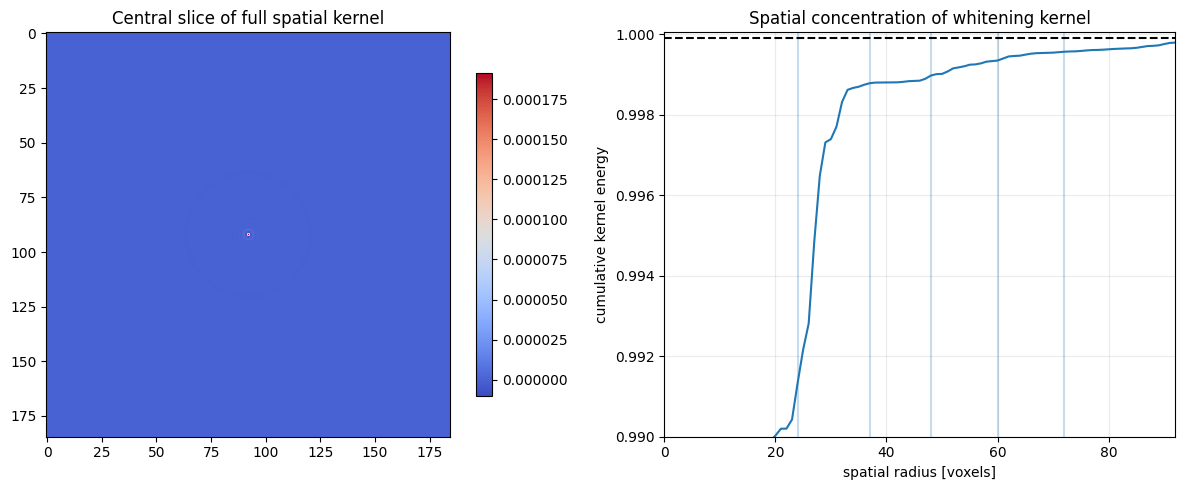

In [6]:
center = design_size // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image = axes[0].imshow(full_kernel[center], cmap="coolwarm")
axes[0].set_title("Central slice of full spatial kernel")
fig.colorbar(image, ax=axes[0], shrink=0.8)

integer_radius = np.floor(spatial_radius).astype(np.int32)
radial_energy = np.bincount(
    integer_radius.ravel(),
    weights=(full_kernel**2).ravel(),
)
cumulative_energy = np.cumsum(radial_energy) / total_kernel_energy
axes[1].plot(cumulative_energy)
for radius in CANDIDATE_RADII:
    axes[1].axvline(radius, alpha=0.25)
axes[1].axhline(MIN_RETAINED_ENERGY, color="black", linestyle="--")
axes[1].set(
    xlabel="spatial radius [voxels]",
    ylabel="cumulative kernel energy",
    title="Spatial concentration of whitening kernel",
    xlim=(0, design_size // 2),
    ylim=(0.99, 1.00005),
)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Compare finite-support candidates

Each candidate uses a radial cosine taper over the outer 20% of its support. We report hard-sphere retained energy separately from the error introduced by the tapered finite kernel.

In [7]:
def radial_taper(radius_grid, support_radius, taper_fraction):
    """Return a unit-center cosine taper that is zero at the support edge."""
    transition_start = support_radius * (1 - taper_fraction)
    transition_width = support_radius - transition_start
    phase = np.clip(
        (radius_grid - transition_start) / transition_width,
        0,
        1,
    )
    taper = 0.5 * (1 + np.cos(np.pi * phase))
    return np.where(radius_grid <= support_radius, taper, 0.0)


def support_metrics(support_radius):
    """Measure spatial energy and frequency error for one support radius."""
    inside = spatial_radius <= support_radius
    retained_energy = np.sum(full_kernel[inside] ** 2) / total_kernel_energy
    window = radial_taper(spatial_radius, support_radius, TAPER_FRACTION)
    tapered_kernel = full_kernel * window
    approximate_response = np.fft.fftshift(
        np.fft.fftn(np.fft.ifftshift(tapered_kernel))
    ).real
    response_difference = approximate_response - whitening_response
    relative_l2_error = (
        np.linalg.norm(response_difference)
        / np.linalg.norm(whitening_response)
    )
    relative_linf_error = (
        np.max(np.abs(response_difference))
        / np.max(np.abs(whitening_response))
    )
    return {
        "radius": int(support_radius),
        "kernel_side": int(2 * support_radius + 1),
        "retained_energy": float(retained_energy),
        "relative_l2_error": float(relative_l2_error),
        "relative_linf_error": float(relative_linf_error),
    }


metrics = [support_metrics(radius) for radius in CANDIDATE_RADII]

print(
    f"{'radius':>8} {'side':>8} {'energy':>14} "
    f"{'relative L2':>14} {'relative Linf':>14}"
)
for item in metrics:
    print(
        f"{item['radius']:8d} {item['kernel_side']:8d} "
        f"{item['retained_energy']:14.8f} "
        f"{item['relative_l2_error']:14.6e} "
        f"{item['relative_linf_error']:14.6e}"
    )

  radius     side         energy    relative L2  relative Linf
      24       49     0.99043081   9.915071e-02   5.225938e-01
      37       75     0.99874850   3.882934e-02   3.150094e-01
      48       97     0.99889653   3.424971e-02   2.637287e-01
      60      121     0.99933390   2.801034e-02   2.456878e-01
      72      145     0.99955629   2.239100e-02   2.334109e-01


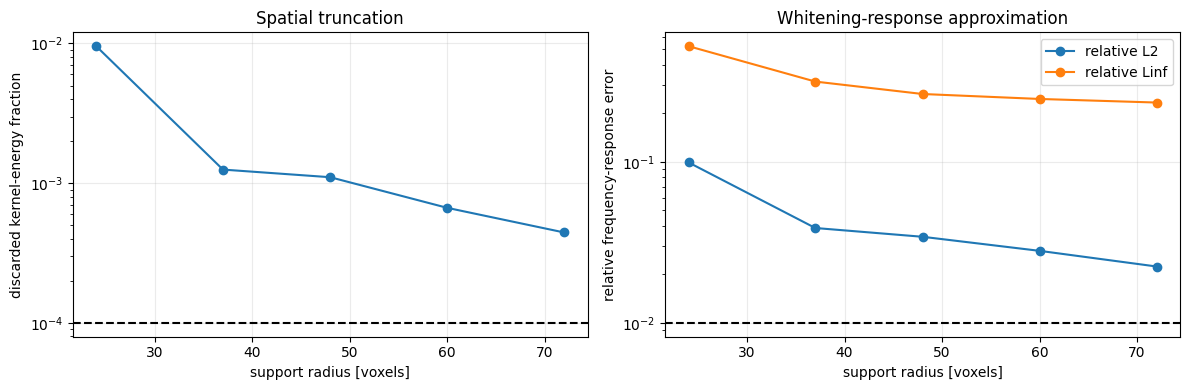

In [8]:
radii = np.asarray([item["radius"] for item in metrics])
energies = np.asarray([item["retained_energy"] for item in metrics])
l2_errors = np.asarray([item["relative_l2_error"] for item in metrics])
linf_errors = np.asarray([item["relative_linf_error"] for item in metrics])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(radii, 1 - energies, marker="o")
axes[0].axhline(1 - MIN_RETAINED_ENERGY, color="black", linestyle="--")
axes[0].set(
    xlabel="support radius [voxels]",
    ylabel="discarded kernel-energy fraction",
    title="Spatial truncation",
    yscale="log",
)
axes[0].grid(alpha=0.25)

axes[1].plot(radii, l2_errors, marker="o", label="relative L2")
axes[1].plot(radii, linf_errors, marker="o", label="relative Linf")
axes[1].axhline(
    MAX_RELATIVE_RESPONSE_ERROR,
    color="black",
    linestyle="--",
)
axes[1].set(
    xlabel="support radius [voxels]",
    ylabel="relative frequency-response error",
    title="Whitening-response approximation",
    yscale="log",
)
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Select, inspect, and save the finite kernel

Automatic threshold selection is reported as a diagnostic. The experiment's configured support is explicitly `SUPPORT_RADIUS = 37`.

In [9]:
eligible_radii = [
    item["radius"]
    for item in metrics
    if item["retained_energy"] >= MIN_RETAINED_ENERGY
    and item["relative_l2_error"] <= MAX_RELATIVE_RESPONSE_ERROR
]
automatic_radius = min(eligible_radii) if eligible_radii else None
selected_radius = SUPPORT_RADIUS

print("Automatically selected radius:", automatic_radius)
print("Configured support radius:", selected_radius)
if selected_radius >= design_size // 2:
    raise ValueError("Selected radius does not fit the kernel-design grid")

Automatically selected radius: None
Effective selected radius: None
No candidate met both thresholds. Inspect the plots, test larger radii/design grids, or set MANUAL_RADIUS explicitly.


In [10]:
if selected_radius is not None:
    finite_kernel = construct_finite_whitening_filter(
        radial_points,
        noise_psd,
        patch_size,
        selected_radius,
        regularization_fraction=REGULARIZATION_FRACTION,
        taper_fraction=TAPER_FRACTION,
    )

    expected_side = 2 * selected_radius + 1
    assert finite_kernel.shape == (expected_side,) * 3

    finite_axis = np.arange(expected_side) - selected_radius
    fz, fy, fx = np.meshgrid(
        finite_axis,
        finite_axis,
        finite_axis,
        indexing="ij",
    )
    finite_distance = np.sqrt(fz**2 + fy**2 + fx**2)
    assert np.all(finite_kernel[finite_distance > selected_radius] == 0)

    np.savez_compressed(
        KERNEL_OUTPUT_PATH,
        kernel=finite_kernel.astype(np.float32),
        support_radius=np.int32(selected_radius),
        design_size=np.int32(design_size),
        patch_size=np.int32(patch_size),
        taper_fraction=np.float64(TAPER_FRACTION),
        regularization_fraction=np.float64(REGULARIZATION_FRACTION),
        radial_points=radial_points,
        noise_psd=noise_psd,
        particle_psd=particle_psd,
    )

    print(f"Finite kernel shape: {finite_kernel.shape}")
    print(f"Required streaming halo: {selected_radius} voxels")
    print(f"Saved: {KERNEL_OUTPUT_PATH}")

    midpoint = selected_radius
    plt.figure(figsize=(6, 5))
    plt.imshow(finite_kernel[midpoint], cmap="coolwarm")
    plt.colorbar(shrink=0.8)
    plt.title(f"Finite whitening kernel, radius={selected_radius}")
    plt.tight_layout()
    plt.show()

## Interpretation and next validation

The saved kernel defines a finite linear filter. A streamed whitening implementation should load each core subvolume with a halo equal to `support_radius`, apply linear convolution, and retain only the core.

Before using it for particle detection, we should compare candidate radii on actual data by checking:

1. Flatness of RPSDs extracted from the whitened volume.
2. Difference from a larger-support reference filter.
3. Numerical seam error at internal subvolume boundaries.
4. Sensitivity to the PSD regularization and taper width.